# Comparative Analysis of Classification Algorithms for Phishing Website Detection

This project compares three machine learning classification algorithms for detecting phishing websites: Random Forest, K-Nearest Neighbors (KNN), and Logistic Regression. The models are evaluated using accuracy, precision, recall, F1-score, and ROC-AUC to determine which approach provides the strongest overall classification performance.

**Dataset:** UCI Phishing Websites Dataset
**Models:** Random Forest, K-Nearest Neighbors, Logistic Regression
**Language:** Python

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

In [2]:
from matplotlib.colors import LinearSegmentedColormap

# Color palette used throughout the notebook
PRIMARY_PINK = "#EC4899"
DARK_PINK = "#C21884"
LIGHT_PINK = "#FCE4EC"
WHITE = "#FFFFFF"

# Create a custom pink color map
ANG_PINK = LinearSegmentedColormap.from_list(
    "ang_pink",
    [WHITE, LIGHT_PINK, PRIMARY_PINK, DARK_PINK]
)

## Pull and load the phishing website dataset from UCI

In [3]:
# Pull the dataset from UCI using pip install ucimlrepo
%pip install ucimlrepo

# Import the UCI dataset repository
from ucimlrepo import fetch_ucirepo

# Fetch the Phishing Websites dataset from UCI
phishing_websites = fetch_ucirepo(id=327)

# Separate the features and target into pandas DataFrames
X = phishing_websites.data.features
y = phishing_websites.data.targets

# Display dataset metadata
print(phishing_websites.metadata)

# Display variable information
print(phishing_websites.variables)



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, 

## Create a single DataFrame for data exploration and preprocessing.

In [4]:
# Create a copy of the feature variables so the original dataset remains unchanged
df = X.copy()

# Add the target variable to the DataFrame so all data can be explored together
df["Result"] = y

# Display the first five rows to verify the dataset was combined correctly
df.head()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## Dataset Exploration

In [5]:
# Display the number of rows and columns in the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (11055, 31)


In [6]:
# Display the data type for each variable
df.dtypes

having_ip_address             int64
url_length                    int64
shortining_service            int64
having_at_symbol              int64
double_slash_redirecting      int64
prefix_suffix                 int64
having_sub_domain             int64
sslfinal_state                int64
domain_registration_length    int64
favicon                       int64
port                          int64
https_token                   int64
request_url                   int64
url_of_anchor                 int64
links_in_tags                 int64
sfh                           int64
submitting_to_email           int64
abnormal_url                  int64
redirect                      int64
on_mouseover                  int64
rightclick                    int64
popupwindow                   int64
iframe                        int64
age_of_domain                 int64
dnsrecord                     int64
web_traffic                   int64
page_rank                     int64
google_index                

In [7]:
# Display summary statistics for the numeric variables
df.describe()

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
# Check if there are any missing values in the dataset
df.isnull().sum()

having_ip_address             0
url_length                    0
shortining_service            0
having_at_symbol              0
double_slash_redirecting      0
prefix_suffix                 0
having_sub_domain             0
sslfinal_state                0
domain_registration_length    0
favicon                       0
port                          0
https_token                   0
request_url                   0
url_of_anchor                 0
links_in_tags                 0
sfh                           0
submitting_to_email           0
abnormal_url                  0
redirect                      0
on_mouseover                  0
rightclick                    0
popupwindow                   0
iframe                        0
age_of_domain                 0
dnsrecord                     0
web_traffic                   0
page_rank                     0
google_index                  0
links_pointing_to_page        0
statistical_report            0
Result                        0
dtype: i

In [9]:
# Count how many websites belong to each class
df["Result"].value_counts()

Result
 1    6157
-1    4898
Name: count, dtype: int64

In [10]:
# Check if there are any duplicate rows in the dataset
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5206


## Dataset Preprocessing

In [11]:
# Separate the feature variables from the target variable
X = df.drop(columns=["Result"])
y = df["Result"]

In [12]:
# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
# Create a standard scaler
scaler = StandardScaler()

# Fit the scaler using the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to the testing data
X_test_scaled = scaler.transform(X_test)

## Train Classification Models

### Random Forest

In [14]:
# Create the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Train the model using the training data
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [15]:
# Use the trained model to make predictions
rf_predictions = rf_model.predict(X_test)

# Calculate the prediction probabilities
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

### K-Nearest Neighbors (KNN)

In [16]:
# Create the K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model using the scaled training data
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[-1, 1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [17]:
# Use the trained model to make predictions
knn_predictions = knn_model.predict(X_test_scaled)

# Calculate the prediction probabilities
knn_probabilities = knn_model.predict_proba(X_test_scaled)[:, 1]

### Logistic Regression

In [18]:
# Create the Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Train the model using the scaled training data
lr_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [19]:
# Use the trained model to make predictions
lr_predictions = lr_model.predict(X_test_scaled)

# Calculate the prediction probabilities
lr_probabilities = lr_model.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

In [22]:
# Calculate the performance metrics for each model
results = pd.DataFrame({
    "Model": ["Random Forest", "K-Nearest Neighbors", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, knn_predictions),
        accuracy_score(y_test, lr_predictions)
    ],
    "Precision": [
        precision_score(y_test, rf_predictions),
        precision_score(y_test, knn_predictions),
        precision_score(y_test, lr_predictions)
    ],
    "Recall": [
        recall_score(y_test, rf_predictions),
        recall_score(y_test, knn_predictions),
        recall_score(y_test, lr_predictions)
    ],
    "F1-Score": [
        f1_score(y_test, rf_predictions),
        f1_score(y_test, knn_predictions),
        f1_score(y_test, lr_predictions)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, knn_probabilities),
        roc_auc_score(y_test, lr_probabilities)
    ]
})

In [23]:
# Round the results to four decimal places for easier reading
results = results.round(4)

# Display the performance results for each model
results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9742,0.9696,0.9846,0.9770,0.9977
1,K-Nearest Neighbors,0.9484,0.9500,0.9578,0.9539,0.9868
2,Logistic Regression,0.9285,0.9234,0.9504,0.9367,0.9808


## Model Performance Visualizations

### Random Forest Confusion Matrix

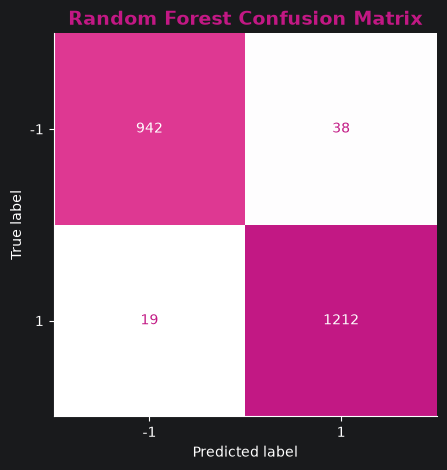

In [28]:
# Display the confusion matrix for the Random Forest model
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    cmap=ANG_PINK,
    colorbar=False
)

# Customize the chart
disp.ax_.set_title(
    "Random Forest Confusion Matrix",
    fontsize=14,
    color=DARK_PINK,
    fontweight="bold"
)

disp.ax_.spines["top"].set_visible(False)
disp.ax_.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### K-Nearest Neighbors Confusion Matrix

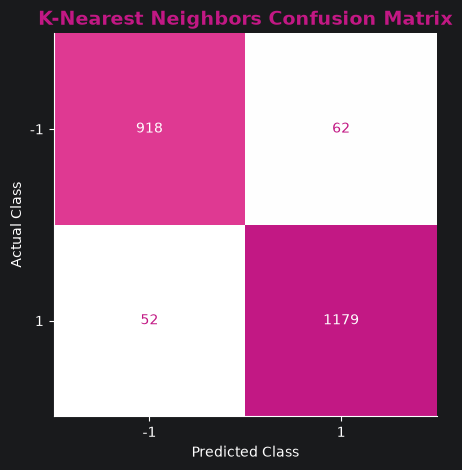

In [29]:
# Display the confusion matrix for the K-Nearest Neighbors model
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_predictions,
    cmap=ANG_PINK,
    colorbar=False
)

# Customize the chart
disp.ax_.set_title(
    "K-Nearest Neighbors Confusion Matrix",
    fontsize=14,
    color=DARK_PINK,
    fontweight="bold"
)

disp.ax_.set_xlabel("Predicted Class")
disp.ax_.set_ylabel("Actual Class")

# Remove the top and right borders
disp.ax_.spines["top"].set_visible(False)
disp.ax_.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### Logistic Regression Confusion Matrix

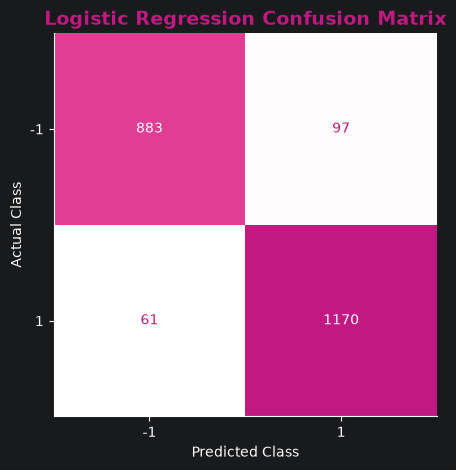

In [30]:
# Display the confusion matrix for the Logistic Regression model
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    cmap=ANG_PINK,
    colorbar=False
)

# Customize the chart
disp.ax_.set_title(
    "Logistic Regression Confusion Matrix",
    fontsize=14,
    color=DARK_PINK,
    fontweight="bold"
)

disp.ax_.set_xlabel("Predicted Class")
disp.ax_.set_ylabel("Actual Class")

# Remove the top and right borders
disp.ax_.spines["top"].set_visible(False)
disp.ax_.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### ROC Curve

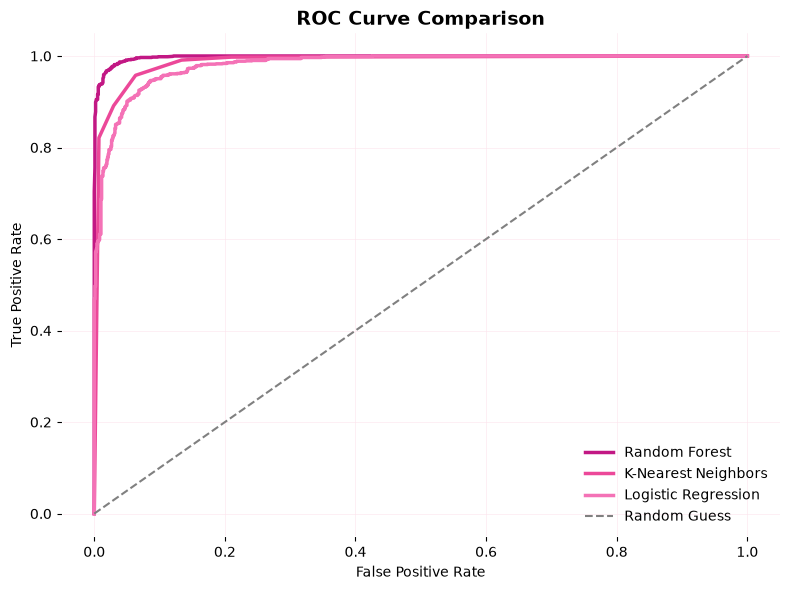

In [31]:
# Calculate the ROC curve for each model
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probabilities)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probabilities)

# Create the figure with a white background
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")

# Plot ROC curves
ax.plot(
    rf_fpr, rf_tpr,
    color=DARK_PINK,
    linewidth=2.5,
    label="Random Forest"
)

ax.plot(
    knn_fpr, knn_tpr,
    color=PRIMARY_PINK,
    linewidth=2.5,
    label="K-Nearest Neighbors"
)

ax.plot(
    lr_fpr, lr_tpr,
    color="#F472B6",
    linewidth=2.5,
    label="Logistic Regression"
)

# Reference line
ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Random Guess"
)

# Customize the chart
ax.set_title(
    "ROC Curve Comparison",
    fontsize=14,
    color="black",
    fontweight="bold"
)

ax.set_xlabel(
    "False Positive Rate",
    color="black"
)

ax.set_ylabel(
    "True Positive Rate",
    color="black"
)

# Make tick labels black
ax.tick_params(
    axis="both",
    colors="black"
)

# Light pink gridlines
ax.grid(
    True,
    color=LIGHT_PINK,
    alpha=0.8
)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Make legend text black
legend = ax.legend(frameon=False)
for text in legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

## Feature Importance

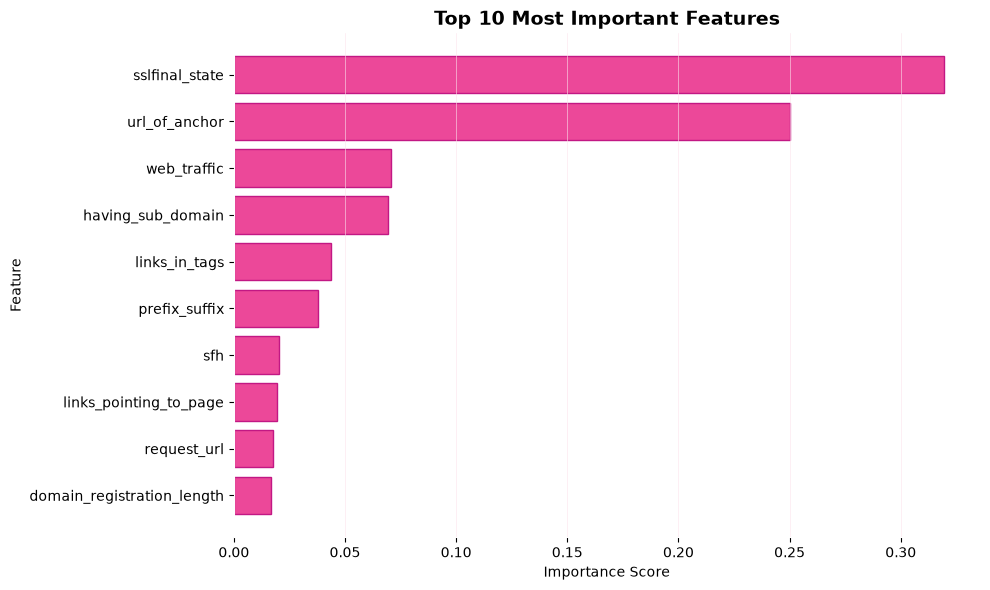

In [32]:
# Create a DataFrame showing the importance of each feature
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort the features from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Select the top 10 most important features
top_features = feature_importance.head(10)

# Create the feature importance chart
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
ax.set_facecolor("white")

ax.barh(
    top_features["Feature"],
    top_features["Importance"],
    color=PRIMARY_PINK,
    edgecolor=DARK_PINK
)

# Display the most important feature at the top
ax.invert_yaxis()

# Customize the chart
ax.set_title(
    "Top 10 Most Important Features",
    fontsize=14,
    color="black",
    fontweight="bold"
)

ax.set_xlabel(
    "Importance Score",
    color="black"
)

ax.set_ylabel(
    "Feature",
    color="black"
)

# Make tick labels black
ax.tick_params(
    axis="both",
    colors="black"
)

# Light pink gridlines
ax.grid(
    axis="x",
    color=LIGHT_PINK,
    alpha=0.8
)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Learning Curves

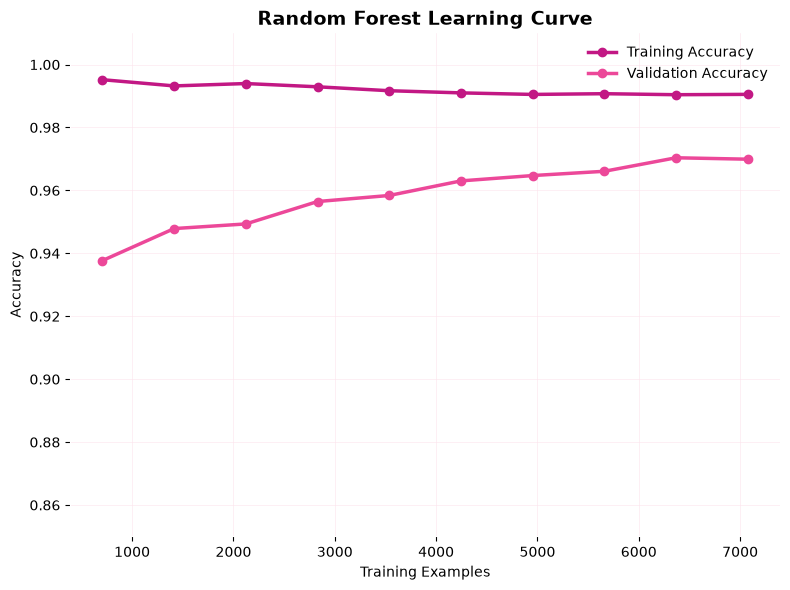

In [33]:
from sklearn.model_selection import learning_curve

# Calculate the learning curve for the Random Forest model
train_sizes, train_scores, test_scores = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Calculate the average training and validation scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Create the learning curve
fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")

# Plot the training accuracy
ax.plot(
    train_sizes,
    train_mean,
    color=DARK_PINK,
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="Training Accuracy"
)

# Plot the validation accuracy
ax.plot(
    train_sizes,
    test_mean,
    color=PRIMARY_PINK,
    linewidth=2.5,
    marker="o",
    markersize=6,
    label="Validation Accuracy"
)

# Customize the chart
ax.set_title(
    "Random Forest Learning Curve",
    fontsize=14,
    color="black",
    fontweight="bold"
)

ax.set_xlabel(
    "Training Examples",
    color="black"
)

ax.set_ylabel(
    "Accuracy",
    color="black"
)

# Make tick labels black
ax.tick_params(
    axis="both",
    colors="black"
)

# Light pink gridlines
ax.grid(True, color=LIGHT_PINK, alpha=0.8)

# Remove top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep the y-axis focused on the meaningful range
ax.set_ylim(0.85, 1.01)

# Make legend text black
legend = ax.legend(frameon=False)
for text in legend.get_texts():
    text.set_color("black")

plt.tight_layout()
plt.show()

## Compare the Performance Metrics

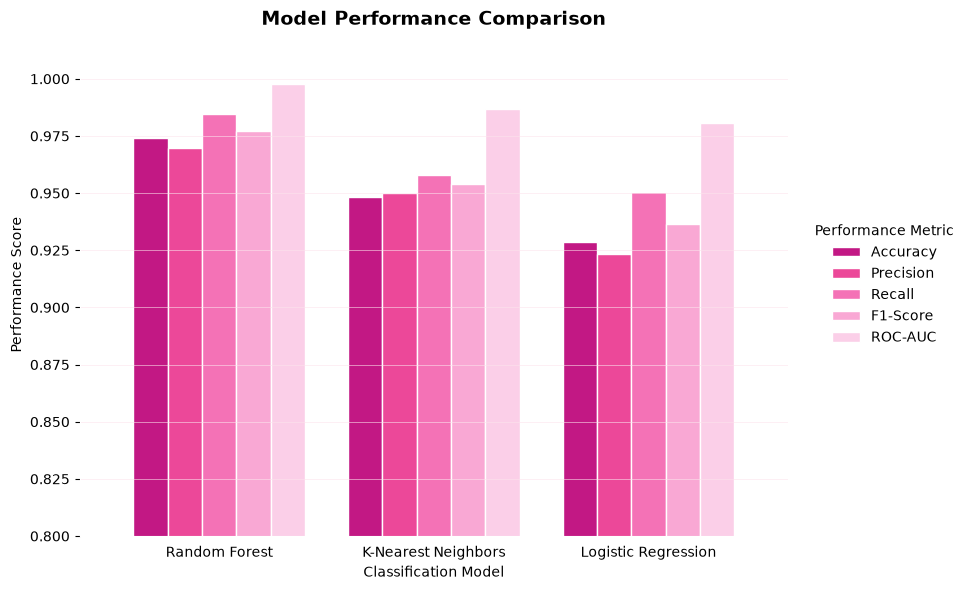

In [35]:
# Create a bar chart to compare the performance of each model
results_plot = results.set_index("Model")

# Create the figure
fig, ax = plt.subplots(figsize=(12, 6), facecolor="white")
ax.set_facecolor("white")

# Plot the grouped bar chart
results_plot.plot(
    kind="bar",
    ax=ax,
    color=[
        DARK_PINK,       # Accuracy
        PRIMARY_PINK,    # Precision
        "#F472B6",       # Recall
        "#F9A8D4",       # F1-Score
        "#FBCFE8",       # ROC-AUC
        "#C21884"        # Average
    ],
    edgecolor="white",
    width=0.8
)

# Customize the chart
ax.set_title(
    "Model Performance Comparison",
    fontsize=14,
    color="black",
    fontweight="bold"
)

ax.set_xlabel(
    "Classification Model",
    color="black"
)

ax.set_ylabel(
    "Performance Score",
    color="black"
)

ax.set_xticklabels(
    results_plot.index,
    rotation=0,
    color="black"
)

ax.tick_params(
    axis="y",
    colors="black"
)

ax.set_ylim(0.80, 1.02)

# Add light pink horizontal gridlines
ax.grid(
    axis="y",
    color=LIGHT_PINK,
    alpha=0.8
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move the legend outside the plot
legend = ax.legend(
    title="Performance Metric",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Make legend title and labels black
legend.get_title().set_color("black")

for text in legend.get_texts():
    text.set_color("black")

# Reserve space on the right for the legend
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

## Results Summary

In [36]:
# Display the model with the highest score for each performance metric
for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    best_model = results.loc[results[metric].idxmax(), "Model"]
    best_score = results[metric].max()

    print(f"Best {metric}: {best_model} ({best_score:.4f})")

Best Accuracy: Random Forest (0.9742)
Best Precision: Random Forest (0.9696)
Best Recall: Random Forest (0.9846)
Best F1-Score: Random Forest (0.9770)
Best ROC-AUC: Random Forest (0.9977)


In [38]:
# Display the final comparison table with the average score included
results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Average Score
0,Random Forest,0.9742,0.9696,0.9846,0.9770,0.9977,0.9806
1,K-Nearest Neighbors,0.9484,0.9500,0.9578,0.9539,0.9868,0.9594
2,Logistic Regression,0.9285,0.9234,0.9504,0.9367,0.9808,0.9440


In [37]:
# Calculate the average performance score for each model
results["Average Score"] = results[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].mean(axis=1)

# Display the model with the highest overall average score
best_overall_model = results.loc[
    results["Average Score"].idxmax(),
    "Model"
]

best_overall_score = results["Average Score"].max()

print(
    f"Best Overall Model: {best_overall_model} "
    f"({best_overall_score:.4f})"
)

Best Overall Model: Random Forest (0.9806)
